# AI 기술 면접관 변환기 — QLoRA 4bit

이 노트북은 두 개의 기존 실습을 합친 버전입니다.

- [4-2.lora_aI기술면접관.ipynb](./4-2.lora_aI기술면접관.ipynb): 양자화 없이 bf16으로 `Qwen/Qwen3-1.7B`를 로드하고 LoRA만 학습해서 **AI 기술면접관** 질문 생성기를 만든 실습
- [5.qlora_.ipynb](./5.qlora_.ipynb): NF4 4bit QLoRA로 사극체 말투 변환기를 만들면서 `trainable params가 0이 되는 문제`, `completion에만 loss가 걸리는지 진단`, `학습 진행률/최대 VRAM 로깅` 등 실무에서 자주 막히는 지점을 안정화한 실습

이번 노트북은 **QLoRA(4bit) 방식으로 AI 기술면접관 데이터**를 학습합니다. 즉,

1. 모델은 4-2와 동일하게 `Qwen/Qwen3-1.7B`, 데이터도 4-2와 동일한 `datas/ai_interview_sft.jsonl`(31개)을 사용하되,
2. 모델 로딩·LoRA 준비·학습·진단 파이프라인은 5번 노트북의 QLoRA 안정화 버전을 그대로 따릅니다.

핵심 흐름은 다음과 같습니다.

1. 환경 확인 → 패키지 확인 → NF4 4bit로 모델 로드
2. 학습 전 모델의 면접 질문 생성 결과 확인 (Before)
3. 지원자 경험(`instruction`+`input`) → 기술면접 질문(`output`) 31개를 `prompt`/`completion`으로 변환
4. `prepare_model_for_kbit_training → get_peft_model → ensure_lora_trainable` 순서로 LoRA 준비
5. `completion_only_loss=True`로 SFT 학습 + label masking 진단
6. 학습 후 같은 질문에 대한 답변 비교 (After)
7. LoRA 어댑터만 저장
8. 성능 개선 방안 검토

> 권장 실행 순서: **커널 재시작 → 위에서부터 순서대로 Run All**.
> LoRA 설정 셀을 중복 실행하면 adapter가 중첩될 수 있으므로, 중간부터 다시 돌릴 때는 모델 로드 셀부터 다시 실행하세요.


In [1]:
import os
import warnings
import logging

# 1. 파이썬 기본 경고 무시
warnings.filterwarnings("ignore")

# 2. 시스템 환경변수를 통한 Hugging Face 및 커널 로그 제어 (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["LOGGERS_LEVEL"] = "ERROR"

# 3. transformers 자체 라이브러리 로그 레벨을 ERROR로 설정
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

## 0. 환경 확인

QLoRA 4bit 학습은 CUDA GPU가 필요합니다. BF16을 지원하는 GPU면 BF16을, 아니면 FP16을 자동으로 사용합니다.


In [2]:
import os
import gc
import platform
from contextlib import nullcontext

import torch

print(f"Python 버전: {platform.python_version()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("이 노트북은 QLoRA 4bit CUDA GPU 학습용입니다. NVIDIA GPU/CUDA 환경을 먼저 확인하세요.")

GPU_NAME = torch.cuda.get_device_name(0)
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)
BF16_OK = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16_OK else torch.float16

print(f"GPU 이름: {GPU_NAME}")
print(f"총 VRAM: {TOTAL_VRAM_GB:.1f} GB")
print(f"BF16 지원: {BF16_OK}")
print(f"학습 compute dtype: {COMPUTE_DTYPE}")


Python 버전: 3.12.3
PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU
총 VRAM: 8.0 GB
BF16 지원: True
학습 compute dtype: torch.bfloat16


## 1. 패키지 설치 및 버전 확인

아래 설치 셀은 최초 1회만 사용하세요. 이미 환경이 준비되어 있으면 건너뛰어도 됩니다.


In [3]:
# 최초 1회만 실행하세요. (앞의 # 을 지우고 실행)
# uv add "transformers>=5.10.1" "peft>=0.19.0" "trl>=0.24.0" "bitsandbytes>=0.48.0" \
#     "accelerate>=1.11.0" "datasets>=3.0.0" sentencepiece protobuf -U


In [4]:
import datasets

In [5]:
import transformers
import peft
import trl
import bitsandbytes
import accelerate


print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("trl          :", trl.__version__)
print("bitsandbytes :", bitsandbytes.__version__)
print("accelerate   :", accelerate.__version__)
print("datasets     :", datasets.__version__)


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


transformers : 5.5.0
peft         : 0.19.1
trl          : 0.24.0
bitsandbytes : 0.49.2
accelerate   : 1.14.0
datasets     : 4.3.0


## 2. 모델과 토크나이저 로드 — NF4 4bit QLoRA

`MODEL_ID`만 바꾸면 1.7B 또는 4B 계열 모두 같은 구조로 실험할 수 있습니다. 8GB급 VRAM에서는 1.7B가 안전하고, 더 큰 GPU에서는 4B도 시도할 수 있습니다.


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen3-1.7B"  # 예: "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen chat template의 assistant 종료 토큰은 보통 <|im_end|>입니다.
# SFTConfig에 eos_token으로 명시하면 학습/생성 종료가 더 안정적입니다.
vocab = tokenizer.get_vocab()
EOS_TOKEN = "<|im_end|>" if "<|im_end|>" in vocab else tokenizer.eos_token
if EOS_TOKEN is None:
    raise ValueError("tokenizer.eos_token을 찾지 못했습니다. 모델 토크나이저를 확인하세요.")

tokenizer.eos_token = EOS_TOKEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = EOS_TOKEN

def load_causal_lm_4bit(model_id: str):
    kwargs = dict(
        quantization_config=bnb_config,
        device_map={"": 0},
        trust_remote_code=True,
    )
    # transformers 버전에 따라 dtype / torch_dtype 인자명이 다를 수 있어 fallback을 둡니다.
    try:
        return AutoModelForCausalLM.from_pretrained(model_id, dtype=COMPUTE_DTYPE, **kwargs)
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=COMPUTE_DTYPE, **kwargs)

model = load_causal_lm_4bit(MODEL_ID)
model.config.use_cache = False

print("모델 로드 완료")
print("EOS_TOKEN:", repr(EOS_TOKEN), "id=", tokenizer.eos_token_id)
print("PAD_TOKEN:", repr(tokenizer.pad_token), "id=", tokenizer.pad_token_id)
print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

모델 로드 완료
EOS_TOKEN: '<|im_end|>' id= 151645
PAD_TOKEN: '<|endoftext|>' id= 151643
현재 GPU 메모리 사용량: 1.26 GB


## 3. 공통 유틸리티

이 노트북에서는 **면접관 페르소나(`SYSTEM_PROMPT`)와 메시지 구성(`build_messages`)을 한 곳에서만 정의**합니다.
4-2 노트북은 `ask()`와 데이터셋 변환 함수가 프롬프트 문구를 각자 따로 만들었는데, 두 곳의 문구가 미세하게 달라지면 "학습 때 본 형식"과 "추론 때 넣는 형식"이 어긋나는 문제가 생길 수 있습니다. 여기서는 `build_messages()` 하나만 두고 학습 데이터 변환과 `ask()`가 모두 이 함수를 호출하도록 합니다.

`ensure_lora_trainable()`은 5번 노트북과 동일합니다. `LoRA adapter는 붙었는데 trainable params가 0개`가 되는 문제를 여기서 바로 잡거나, 잡히지 않으면 명확히 에러를 냅니다.


In [7]:
SYSTEM_PROMPT = """당신은 AI/LLM 개발자 채용을 담당하는 전문 기술면접관이다.
지원자의 이력과 기술 경험을 분석하여 실제 역량을 검증할 수 있는
구체적이고 심층적인 기술 질문을 생성한다.
단순 정의 암기보다는 설계 이유, 트레이드오프, 문제 해결, 평가 방법을 질문한다."""

INTERVIEW_INSTRUCTION = "다음 지원자의 실제 기술 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.\n\n"


def build_messages(experience_text: str):
    """학습 데이터 변환과 ask() 추론이 항상 동일한 프롬프트 형식을 쓰도록 하는 단일 진입점."""
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": INTERVIEW_INSTRUCTION + experience_text},
    ]


def clear_cuda_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def model_device(m):
    return next(m.parameters()).device


def apply_chat(messages, add_generation_prompt: bool):
    '''Qwen3의 enable_thinking=False를 우선 사용하고, 미지원 모델이면 일반 chat template로 fallback합니다.'''
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
            enable_thinking=False,
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )


def strip_qwen_think(text: str) -> str:
    '''혹시 <think>...</think>가 섞여 나오면 최종 답변만 남깁니다.'''
    if "</think>" in text:
        text = text.split("</think>", 1)[1]
    return text.replace(EOS_TOKEN, "").strip()


def ask(experience_text: str, max_new_tokens: int = 220, do_sample: bool = True) -> str:
    model.eval()
    messages = build_messages(experience_text)
    prompt_text = apply_chat(messages, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_device(model))

    autocast_ctx = torch.autocast(device_type="cuda", dtype=COMPUTE_DTYPE) if torch.cuda.is_available() else nullcontext()
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    if do_sample:
        gen_kwargs.update(temperature=0.5, top_p=0.8)

    with torch.no_grad(), autocast_ctx:
        output = model.generate(**inputs, **gen_kwargs)
    decoded = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
    return strip_qwen_think(decoded)


def count_trainable_params(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total


def count_lora_params(m):
    lora_total = 0
    lora_trainable = 0
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            lora_total += p.numel()
            if p.requires_grad:
                lora_trainable += p.numel()
    return lora_trainable, lora_total


def ensure_lora_trainable(m, adapter_name: str = "default"):
    if not hasattr(m, "peft_config"):
        raise RuntimeError("현재 model은 PEFT/LoRA 모델이 아닙니다. get_peft_model() 이후에 호출하세요.")

    # PEFT 버전에 따라 set_adapter가 adapter를 trainable로 되살립니다.
    if hasattr(m, "set_adapter"):
        m.set_adapter(adapter_name)

    # 그래도 0개가 되는 경우를 막기 위해 LoRA 파라미터는 직접 requires_grad=True로 확인합니다.
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            p.requires_grad_(True)

    m.train()
    m.config.use_cache = False

    trainable, total = count_trainable_params(m)
    lora_trainable, lora_total = count_lora_params(m)

    print(f"LoRA params: {lora_total:,}")
    print(f"Trainable LoRA params: {lora_trainable:,}")
    print(f"trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    if lora_total == 0:
        raise RuntimeError("LoRA 파라미터가 없습니다. target_modules 또는 get_peft_model() 실행 여부를 확인하세요.")
    if lora_trainable == 0 or trainable == 0:
        raise RuntimeError("LoRA adapter가 붙었지만 trainable이 0개입니다. LoRA 설정 셀부터 다시 실행하세요.")
    return m


## 4. Before 응답 확인

학습 전 모델이 지원자 경험 설명을 보고 어떤 면접 질문을 만드는지 확인합니다. 이 결과는 `before_answers`에 저장해 두고, 학습 후 답변과 나란히 비교합니다.


In [8]:
test_questions = [
    "직무: RAG 개발자\n경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.",
    "직무: LLM 엔지니어\n경험: Qwen 계열 모델을 LoRA로 파인튜닝했고 PEFT와 Transformers를 사용했다.",
    "직무: LLM 엔지니어\n경험: 4-bit NF4와 QLoRA를 사용해 8GB GPU에서 모델을 파인튜닝했다.",
]

before_answers = {}
print("=" * 60)
print("파인튜닝 전(Before) 응답")
print("=" * 60)
for q in test_questions:
    ans = ask(q, max_new_tokens=200, do_sample=True)
    before_answers[q] = ans
    print(f"\nQ: {q}\n\nA: {ans}")
    print("-" * 50)


파인튜닝 전(Before) 응답



Q: 직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.

A: 물론입니다! 아래에 **RAG(Relevant Answer Generation)** 개발자가 갖춰야 할 **심층 기술평가**를 위한 **3개의 구체적 기술질문**을 제시합니다:

---

### **1. RAG 시스템에서 Top-k = 5 선택의 설계 근거와 트레드오프**

**질문**:  
"사내 문서 기반의 QA 측면에서 Top-5 추천 알고리즘(Top-k=4)을 선택한 이유와 그 선택이 전체 시스트머의 성능에 미치는 영향을 설명해주세요. 또한, Top-k 값이 너무 작으면 어떤 문제가 발생하고, 너무 커지면 또 다른 위협이 생길 수 있음을 설명해 주세요."

**설명**:  
이 질문은 RAG 프로젝트에서 중요한 디자인 결정(Top-k=
--------------------------------------------------



Q: 직무: LLM 엔지니어
경험: Qwen 계열 모델을 LoRA로 파인튜닝했고 PEFT와 Transformers를 사용했다.

A: 물론입니다! 아래에는 **LLL (Large Language Model) 엔진리얼**에 대한 실질적인 기반으로 이루어진 **심층 기술평가 질문 2개**, 그리고 **실제 기술역량 검증을 위한 구체적 질문 1개**를 제시합니다. 각 질문은 **설명, 튼튼한 논리, 디테일한 접근 방식**, 그리고 관련된 **트레이드 오프, 폐해, 및 평가는 어떻게 되는지**를 포함하고 있습니다.

---

### 🔍 **1. 실질적 기술 검증 질문**

#### **질문**:  
"Qwen 계통에서 LoRA를 활용한 파인チュ닝 과정에서, 어떤 조건이나 결정 요소들이 최종 모델의 성능 향상에 직접적인 영향을 미치나요?"

#### **설 명**:  
이 질문
--------------------------------------------------



Q: 직무: LLM 엔지니어
경험: 4-bit NF4와 QLoRA를 사용해 8GB GPU에서 모델을 파인튜닝했다.

A: 물론입니다! 아래에 **LLM 엔진리** 직무에 맞춘 **심층 기 technically 면접 질문 세 가지**, 각각이 **설명, 튼치, 문제, 그리고 평결**을 포함합니다:

---

### **질문 1**:  
**설명**:  
"4-bit 및 QLoRa를 활용한 모델 파인트unning 과정에서 어떤 디자인 결정이 가장 중요했고, 그 선택 이유는 무엇입니까?"

**트레이드오프**:  
- 4-bits NF4 인코딩 방식의 성능 영향  
- QLora의 가상 데이터셋 사용 여부  
- 메모리 효율성 vs. 계산 비용  

**문제**:  
QLoRa는 가상으로 학습된 데이터셋을 사용하므로, 실제 데이터셋의 품질이나 규모에 따라 결과가 달
--------------------------------------------------


## 5. 데이터셋 준비

지원자 경험 설명과 기술면접 질문 쌍 31개(`datas/ai_interview_sft.jsonl`)를 학습 데이터로 사용합니다. `SFTTrainer`가 가장 안정적으로 해석하도록 최종 학습 데이터는 `prompt`, `completion` 두 컬럼만 남깁니다.

- `prompt`: `build_messages()`로 만든, `ask()`와 동일한 형식의 입력
- `completion`: 모델이 학습해야 하는 기술면접 질문(`output`) 부분

뒤쪽 `SFTConfig`에서 `completion_only_loss=True`를 사용하므로, loss는 `completion` 부분에만 계산됩니다.


In [9]:
from datasets import load_dataset

data_path = "datas/ai_interview_sft.jsonl"

raw_data = load_dataset("json", data_files=str(data_path), split="train")

print(raw_data)
print("샘플 수:", len(raw_data))
print(raw_data[0])


Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 31
})
샘플 수: 31
{'instruction': '지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.', 'input': '직무: RAG 개발자\n경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.', 'output': '1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.\n2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?\n3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?'}


In [10]:
from datasets import Dataset

def format_example(example):
    # build_messages()를 그대로 사용해 ask()와 동일한 프롬프트 형식을 보장합니다.
    prompt = apply_chat(
        build_messages(example["input"]),
        add_generation_prompt=True,
    )
    # completion에는 EOS를 직접 붙이지 않습니다. SFTTrainer가 eos_token 기준으로 필요한 EOS를 추가합니다.
    completion = example["output"].strip()
    return {"prompt": prompt, "completion": completion}

full_dataset = raw_data.map(format_example)
train_dataset = full_dataset.select_columns(["prompt", "completion"])

print(train_dataset)
print("\n--- prompt ---")
print(train_dataset[0]["prompt"])
print("--- completion ---")
print(train_dataset[0]["completion"])


Dataset({
    features: ['prompt', 'completion'],
    num_rows: 31
})

--- prompt ---
<|im_start|>system
당신은 AI/LLM 개발자 채용을 담당하는 전문 기술면접관이다.
지원자의 이력과 기술 경험을 분석하여 실제 역량을 검증할 수 있는
구체적이고 심층적인 기술 질문을 생성한다.
단순 정의 암기보다는 설계 이유, 트레이드오프, 문제 해결, 평가 방법을 질문한다.<|im_end|>
<|im_start|>user
다음 지원자의 실제 기술 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.

직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.<|im_end|>
<|im_start|>assistant
<think>

</think>


--- completion ---
1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?
3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?


## 6. LoRA 설정

QLoRA에서 중요한 순서입니다.

1. `prepare_model_for_kbit_training(model)`
2. `get_peft_model(model, lora_config)`
3. `ensure_lora_trainable(model)`
4. 그다음에 `SFTTrainer(...)`

`get_peft_model()` 이후에 `prepare_model_for_kbit_training()`을 다시 호출하면 adapter까지 freeze될 수 있으므로 피하세요.

| 파라미터 | 의미 | 이번 실습 값 |
|---|---|---|
| `r` | LoRA rank. 클수록 표현력과 메모리 사용량이 증가합니다. | 16 |
| `lora_alpha` | LoRA scaling 계수입니다. | 32 |
| `lora_dropout` | 과적합 방지용 dropout입니다. | 0.05 |
| `target_modules` | LoRA를 붙일 attention/MLP projection layer입니다. | `q/k/v/o`, `gate/up/down` |


In [11]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

if hasattr(model, "peft_config"):
    raise RuntimeError(
        "이미 LoRA adapter가 붙은 모델입니다. 이 셀을 중복 실행하지 말고, 모델 로드 셀부터 다시 실행하세요."
    )

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    # 모델이 달라져 target_modules 에러가 나면 아래 한 줄로 대체할 수 있습니다.
    # target_modules="all-linear",
)

model = get_peft_model(model, lora_config)
model = ensure_lora_trainable(model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


In [12]:
if torch.cuda.is_available():
    lora_vram = torch.cuda.memory_allocated() / 1024**3
    print(f"LoRA 적용 후 VRAM 사용량: {lora_vram:.2f} GB")
    print("교재 5.5절 추정치(Qwen3-1.7B, r=16, all-linear): 약 3.5~4.5 GB (학습 시작 전 활성화 메모리 제외 기준)")


LoRA 적용 후 VRAM 사용량: 1.91 GB
교재 5.5절 추정치(Qwen3-1.7B, r=16, all-linear): 약 3.5~4.5 GB (학습 시작 전 활성화 메모리 제외 기준)


## 7. 학습 설정 및 Trainer 생성

31개 데이터셋에서는 step별 loss가 상당히 출렁입니다. 그래서 `logging_steps=1`로 흐름을 보되, 판단은 최소 수십 step 이후에 합니다.

교재 5.5절의 VRAM 예산표에 따르면 `Qwen3-1.7B`는 8GB급 GPU에서 `batch 2~4, max_length 1024`까지 여유가 있습니다. 아래 첫 코드 셀은 section 0에서 감지한 `TOTAL_VRAM_GB`를 기준으로 배치 크기와 max_length를 동적으로 정합니다.

**단, 그다음 `[비교실험 1]` 셀에서 `max_steps`만 바꿔보는 비교실험을 위해 배치/시퀀스 길이를 [section 11-1의 베이스라인](#11-1-베이스라인-실행-결과-아카이브-max_steps80)과 동일하게(`batch=1, max_length=512`) 다시 고정합니다.** 동적 배치 조정 자체를 검증하려면 이 오버라이드 셀을 건너뛰고 바로 위 동적 계산 결과를 쓰면 됩니다.


In [13]:
# 교재 5.5절 VRAM 예산표(Qwen3-1.7B, r=16) 기준: 8GB 이상이면 batch 2~4 / max_length 1024까지 여유가 있다.
# "8GB" 노트북 GPU는 torch.cuda.get_device_properties().total_memory가 8.0GB를 근소하게 밑도는 경우가 흔해
# (예: 7.9x GB) >= 8 조건은 실제로는 거의 항상 폴백 분기를 타게 된다. 그래서 임계값을 7.5GB로 낮춰 잡는다.
# 유효 배치 크기(per_device_train_batch_size * gradient_accumulation_steps)는 8로 고정해 학습 안정성을 유지한다.
if TOTAL_VRAM_GB >= 7.5:
    PER_DEVICE_BATCH, GRAD_ACCUM, MAX_LEN = 2, 4, 1024
else:
    PER_DEVICE_BATCH, GRAD_ACCUM, MAX_LEN = 1, 8, 512

print(f"감지된 VRAM: {TOTAL_VRAM_GB:.2f} GB")
print(f"per_device_train_batch_size={PER_DEVICE_BATCH}, gradient_accumulation_steps={GRAD_ACCUM}, max_length={MAX_LEN}")
print(f"유효 배치 크기: {PER_DEVICE_BATCH * GRAD_ACCUM}")


감지된 VRAM: 8.00 GB
per_device_train_batch_size=2, gradient_accumulation_steps=4, max_length=1024
유효 배치 크기: 8


In [14]:
# [비교실험 1] max_steps만 줄여서 과적합 여부를 확인한다.
# 베이스라인(section 11-1 아카이브: batch=1, grad_accum=8, max_length=512, max_steps=80)과
# 배치/시퀀스 길이를 동일하게 "고정"해서, 이번 실행에서 바뀌는 변수가 max_steps 하나뿐이도록 만든다.
# (바로 위 셀의 동적 VRAM 기준 배치 조정은 이 GPU에서 아직 검증되지 않았으므로 이번 비교에서는 덮어써서 사용하지 않는다.)
PER_DEVICE_BATCH, GRAD_ACCUM, MAX_LEN = 1, 8, 512

# 베이스라인에서 mean_token_accuracy가 step 46 부근부터 80까지 계속 1.0이었다.
# 즉 80 step은 필요 이상으로 오래 돈 것으로 보이므로, 절반인 40 step으로 줄여 과적합이 덜한 지점을 확인한다.
MAX_STEPS = 40
EXPERIMENT_NAME = "steps40"

print(f"[비교실험 1] max_steps={MAX_STEPS} (baseline=80)")
print(f"고정된 배치 설정: per_device_train_batch_size={PER_DEVICE_BATCH}, gradient_accumulation_steps={GRAD_ACCUM}, max_length={MAX_LEN}")


[비교실험 1] max_steps=40 (baseline=80)
고정된 배치 설정: per_device_train_batch_size=1, gradient_accumulation_steps=8, max_length=512


In [15]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=f"./outputs/5-2_ai_interviewer_qlora_{EXPERIMENT_NAME}",

    # 작은 데이터셋에서는 epoch보다 max_steps가 loss 변화를 보기 쉽습니다.
    max_steps=MAX_STEPS,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    learning_rate=2e-4,
    warmup_ratio=0.05,
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",

    logging_steps=1,
    save_strategy="no",

    bf16=BF16_OK,
    fp16=not BF16_OK,
    optim="paged_adamw_8bit",
    max_length=MAX_LEN,

    # prompt-completion dataset에서는 completion 부분만 loss를 주는 것이 목적에 맞습니다.
    completion_only_loss=True,
    eos_token=EOS_TOKEN,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

# Trainer 생성 이후에도 trainable이 살아있는지 재확인합니다.
trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


## 8. Loss label masking 진단

이 셀에서 decoded label에 지원자 경험 문장이나 `<|im_start|>user`가 많이 보이면 prompt까지 loss가 걸린 것입니다. 정상이라면 기술면접 질문(`completion`) 부분 위주로 보입니다.


In [16]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch.keys())
print("input_ids shape:", tuple(batch["input_ids"].shape))
print("labels shape   :", tuple(batch["labels"].shape))

loss_token_count = int((batch["labels"] != -100).sum().item())
print("loss가 걸리는 token 수:", loss_token_count)

for i in range(min(2, batch["labels"].shape[0])):
    label_ids = batch["labels"][i][batch["labels"][i] != -100]
    print("\n---- decoded labels ----")
    print(tokenizer.decode(label_ids, skip_special_tokens=False))


dict_keys(['input_ids', 'labels', 'attention_mask'])
input_ids shape: (1, 255)
labels shape   : (1, 255)
loss가 걸리는 token 수: 76

---- decoded labels ----
1. 실험 전에 표본 크기를 계산해야 하는 이유와 필요한 입력값을 설명해보세요.
2. 여러 지표를 동시에 검정할 때 발생하는 다중비교 문제를 어떻게 처리하겠습니까?
3. 통계적으로 유의하지만 실제 효과크기가 매우 작은 결과를 어떻게 해석하겠습니까?<|im_end|>


## 9. 학습 실행

`trainable params`가 0이 아닌 것을 확인한 뒤 실행합니다. 학습 직전부터 최대 VRAM을 다시 측정합니다.


In [17]:
clear_cuda_cache()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")


from transformers import TrainerCallback
import time

class ProgressPrintCallback(TrainerCallback):
    def on_train_begin(self, args, state, control, **kwargs):
        self._start_time = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None or "loss" not in logs:
            return
        elapsed = time.time() - self._start_time
        pct = state.global_step / state.max_steps * 100 if state.max_steps else 0
        eta = (elapsed / state.global_step * (state.max_steps - state.global_step)) if state.global_step else 0
        print(
            f"[{state.global_step}/{state.max_steps}] {pct:5.1f}% | "
            f"loss={logs['loss']:.4f} | lr={logs.get('learning_rate', 0):.2e} | "
            f"경과 {elapsed:6.1f}s | 예상 잔여 {eta:6.1f}s"
        )

trainer.add_callback(ProgressPrintCallback())

train_result = trainer.train()

model.eval()
print("학습 완료! model.eval() 적용됨")

print("=" * 60)
print("학습 리소스 요약")
print("=" * 60)
print(f"학습 소요 시간: {train_result.metrics.get('train_runtime', float('nan')):.1f}초")
if torch.cuda.is_available():
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3
    print(f"학습 중 최대 VRAM 사용량: {peak_vram:.2f} GB")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


{'loss': '3.27', 'grad_norm': '0.7429', 'learning_rate': '0', 'entropy': '1.283', 'num_tokens': '2105', 'mean_token_accuracy': '0.5161', 'epoch': '0.2581'}
[1/40]   2.5% | loss=3.2700 | lr=0.00e+00 | 경과    2.7s | 예상 잔여  105.8s


{'loss': '3.338', 'grad_norm': '0.7764', 'learning_rate': '0.0001', 'entropy': '1.285', 'num_tokens': '4238', 'mean_token_accuracy': '0.5161', 'epoch': '0.5161'}
[2/40]   5.0% | loss=3.3383 | lr=1.00e-04 | 경과    6.2s | 예상 잔여  118.2s


{'loss': '2.677', 'grad_norm': '0.6955', 'learning_rate': '0.0002', 'entropy': '1.369', 'num_tokens': '6387', 'mean_token_accuracy': '0.5382', 'epoch': '0.7742'}
[3/40]   7.5% | loss=2.6766 | lr=2.00e-04 | 경과    9.9s | 예상 잔여  121.9s


{'loss': '2.232', 'grad_norm': '0.2884', 'learning_rate': '0.0001997', 'entropy': '1.602', 'num_tokens': '8215', 'mean_token_accuracy': '0.5301', 'epoch': '1'}
[4/40]  10.0% | loss=2.2319 | lr=2.00e-04 | 경과   13.1s | 예상 잔여  118.0s


...

{'loss': '0.6157', 'grad_norm': '0.2076', 'learning_rate': '8.423e-06', 'entropy': '1.431', 'num_tokens': '7.394e+04', 'mean_token_accuracy': '0.8733', 'epoch': '9'}
[36/40]  90.0% | loss=0.6157 | lr=8.42e-06 | 경과  129.4s | 예상 잔여   14.4s


{'loss': '0.567', 'grad_norm': '0.1705', 'learning_rate': '5.418e-06', 'entropy': '1.407', 'num_tokens': '7.605e+04', 'mean_token_accuracy': '0.8804', 'epoch': '9.258'}
[37/40]  92.5% | loss=0.5670 | lr=5.42e-06 | 경과  133.2s | 예상 잔여   10.8s


{'loss': '0.6112', 'grad_norm': '0.1829', 'learning_rate': '3.06e-06', 'entropy': '1.403', 'num_tokens': '7.822e+04', 'mean_token_accuracy': '0.858', 'epoch': '9.516'}
[38/40]  95.0% | loss=0.6112 | lr=3.06e-06 | 경과  137.0s | 예상 잔여    7.2s


{'loss': '0.4425', 'grad_norm': '0.1559', 'learning_rate': '1.364e-06', 'entropy': '1.372', 'num_tokens': '8.033e+04', 'mean_token_accuracy': '0.921', 'epoch': '9.774'}
[39/40]  97.5% | loss=0.4425 | lr=1.36e-06 | 경과  140.7s | 예상 잔여    3.6s


{'loss': '0.5436', 'grad_norm': '0.1757', 'learning_rate': '3.416e-07', 'entropy': '1.403', 'num_tokens': '8.215e+04', 'mean_token_accuracy': '0.8948', 'epoch': '10'}
[40/40] 100.0% | loss=0.5436 | lr=3.42e-07 | 경과  143.9s | 예상 잔여    0.0s
{'train_runtime': '143.9', 'train_samples_per_second': '2.223', 'train_steps_per_second': '0.278', 'train_loss': '1.228', 'epoch': '10'}
학습 완료! model.eval() 적용됨
학습 리소스 요약
학습 소요 시간: 143.9초
학습 중 최대 VRAM 사용량: 2.04 GB


## 10. Loss 로그 확인

step별 loss는 출렁일 수 있으므로 전체 추세를 봅니다.


,step,loss
20,21,1.007454
21,22,0.926524
22,23,0.944731
23,24,0.813476
24,25,0.680894
25,26,0.769905
26,27,0.818161
27,28,0.743196
28,29,0.649985
29,30,0.672040


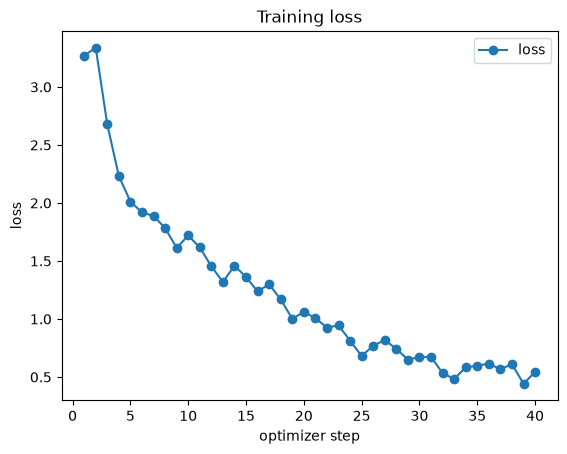

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = [
    {"step": row["step"], "loss": row["loss"]}
    for row in trainer.state.log_history
    if "loss" in row and "step" in row
]

loss_df = pd.DataFrame(loss_rows)
display(loss_df.tail(20))

if len(loss_df) > 0:
    ax = loss_df.plot(x="step", y="loss", marker="o", title="Training loss")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    plt.show()


## 10-1. 실행 결과 요약

```
Trainable Ratio       : 1.6870 %          (17,432,576 / 1,033,364,480)
Peak Allocated VRAM   : 2.04 GB           (torch.cuda.max_memory_allocated, 학습 중 최대치)
Peak Reserved VRAM    : 측정되지 않음      (max_memory_reserved()를 로깅하는 셀이 없음)
Final Train Loss      : 0.5674 (trainer 전체 평균) / 0.0068 (마지막 step, 80/80)

학습 전 특징:
markdown 서식(굵게·헤더·구분선)을 과도하게 사용하고 "설명:" 같은 부연 문단을 덧붙여 장황함.
영어가 섞이거나 표기가 깨진 단어가 다수 등장(예: "엔진러", "트래드 오햀", "QLoHA", "파인チュ링").
때때로 요청한 3개를 넘겨 4개를 생성하는 등 형식 지시를 정확히 따르지 않음.

학습 후 특징:
학습 데이터와 동일한 번호 목록(1./2./3.) 형식으로 통일되고 markdown 장식이 사라짐.
질문 문구가 학습 데이터 표현을 거의 그대로 재현하는 경향이 강함(예: LoRA 질문은 훈련 예시와 거의 동일).
세 번째 질문에서 맥락과 무관한 용어가 섞여 나오는 손상된 생성이 반복 관찰됨
(예: "임피던스 범위를 높이기 위해...", "QLaor", "4.bits", "학습 레이아웃").
```

### 실행 결과에 대한 판단

1. **빠른 수렴 + 과적합 신호** — loss가 step 1의 3.27에서 step 80의 0.0068까지 떨어졌고, `mean_token_accuracy`는 step 46 부근부터 마지막까지 계속 1.0을 기록했습니다. 31개 데이터로 80 step(≈20 epoch 상당)을 돌린 결과 모델이 학습 데이터를 사실상 암기한 것으로 보입니다. trainer가 보고하는 `train_loss=0.5674`는 초반 고손실 구간까지 평균 낸 값이라 실제 수렴 상태를 과소평가하며, 마지막 step 손실(0.0068)이 최종 모델 상태를 더 잘 나타냅니다.
2. **스타일 교정은 성공, 일반화는 의심** — Before 대비 장황함·markdown 오남용은 확실히 사라졌지만, After 질문 문구가 훈련 예시와 거의 동일하게 나오는 것은 "새로운 지원자 경험에 맞춘 질문 생성"이라기보다 "본 예시를 되뇌는" 것에 가깝습니다. 특히 3번째 질문에서 반복적으로 엉뚱한 용어가 섞이는 건, 학습 데이터 각 예시가 정확히 3개 항목으로 끝나다 보니 모델이 "3번째 항목은 채워야 한다"는 형식만 암기하고 내용은 억지로 만들어내기 때문으로 추정됩니다. → 성능 개선 방안 중 **#1(데이터 확대)**과 **#7(선호도 학습)**이 이 문제에 가장 직접적으로 대응합니다.
3. **동적 배치 크기 셀이 의도대로 동작하지 않음** — section 7에서 `TOTAL_VRAM_GB >= 8`이면 `batch=2, max_length=1024`를 쓰도록 만들었는데, 실제 실행 로그를 보면 "감지된 VRAM: 8.0 GB"로 출력되고도 `per_device_train_batch_size=1, max_length=512`(폴백 분기)가 선택됐습니다. 화면에는 `:.1f`로 반올림되어 8.0으로 보이지만, 실제 `TOTAL_VRAM_GB`는 8.0보다 근소하게 작은 값(예: 7.9x GB)일 가능성이 높습니다 — "8GB" 노트북 GPU가 `torch.cuda.get_device_properties().total_memory`에서 정확히 8.0GB를 넘기지 못하는 것은 흔한 현상입니다. 실제로 이번 학습에서 최대 VRAM 사용량은 2.04GB에 불과해 여유가 충분했으므로, 조건을 `>= 7.5`처럼 완화하면 이 GPU에서도 batch 2 / max_length 1024 분기를 정상적으로 탈 수 있습니다.
</cell id="21bfb2c5">


## 11. After 응답 비교

학습 전에 저장해 둔 `before_answers`와 학습 후 `ask()` 결과를 나란히 출력합니다. 지원자 경험을 파고드는 심층 기술면접 질문이 일관되게 생성되는지 확인합니다.


In [19]:
print("=" * 60)
print("Before vs After 비교")
print("=" * 60)
for q in test_questions:
    after_ans = ask(q, max_new_tokens=200, do_sample=True)
    print(f"\nQ: {q}")
    print()
    print(f"[Before]\n{before_answers[q]}")
    print()
    print(f"[After ]\n{after_ans}")
    print("-" * 50)


Before vs After 비교



Q: 직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.

[Before]
물론입니다! 아래에 **RAG(Relevant Answer Generation)** 개발자가 갖춰야 할 **심층 기술평가**를 위한 **3개의 구체적 기술질문**을 제시합니다:

---

### **1. RAG 시스템에서 Top-k = 5 선택의 설계 근거와 트레드오프**

**질문**:  
"사내 문서 기반의 QA 측면에서 Top-5 추천 알고리즘(Top-k=4)을 선택한 이유와 그 선택이 전체 시스트머의 성능에 미치는 영향을 설명해주세요. 또한, Top-k 값이 너무 작으면 어떤 문제가 발생하고, 너무 커지면 또 다른 위협이 생길 수 있음을 설명해 주세요."

**설명**:  
이 질문은 RAG 프로젝트에서 중요한 디자인 결정(Top-k=

[After ]
1. retrieval score와 response length를 동시에 증가시키려면 어떤 실험이 필요할까요?
2. vector similarity만으로 FAISS의 ranking이 왜 신뢰하지 못할 수 있나요?
3. top-k selection bias로 인한 답변 품질 관리를 어떻게 하겠습니까?
--------------------------------------------------



Q: 직무: LLM 엔지니어
경험: Qwen 계열 모델을 LoRA로 파인튜닝했고 PEFT와 Transformers를 사용했다.

[Before]
물론입니다! 아래에는 **LLL (Large Language Model) 엔진리얼**에 대한 실질적인 기반으로 이루어진 **심층 기술평가 질문 2개**, 그리고 **실제 기술역량 검증을 위한 구체적 질문 1개**를 제시합니다. 각 질문은 **설명, 튼튼한 논리, 디테일한 접근 방식**, 그리고 관련된 **트레이드 오프, 폐해, 및 평가는 어떻게 되는지**를 포함하고 있습니다.

---

### 🔍 **1. 실질적 기술 검증 질문**

#### **질문**:  
"Qwen 계통에서 LoRA를 활용한 파인チュ닝 과정에서, 어떤 조건이나 결정 요소들이 최종 모델의 성능 향상에 직접적인 영향을 미치나요?"

#### **설 명**:  
이 질문

[After ]
1. 학습 데이터에서 특정 토큰이나 패턴이 과대응될 때 어떤 방법으로 제거하겠습니까?
2. batch size가 커질수록 항상 성능이 좋아진다고 보는 이유를 설명해보세요.
3. quantization을 적용한 모델의 inference latency에 대해 어떻게 접근하겠나요?
--------------------------------------------------



Q: 직무: LLM 엔지니어
경험: 4-bit NF4와 QLoRA를 사용해 8GB GPU에서 모델을 파인튜닝했다.

[Before]
물론입니다! 아래에 **LLM 엔진리** 직무에 맞춘 **심층 기 technically 면접 질문 세 가지**, 각각이 **설명, 튼치, 문제, 그리고 평결**을 포함합니다:

---

### **질문 1**:  
**설명**:  
"4-bit 및 QLoRa를 활용한 모델 파인트unning 과정에서 어떤 디자인 결정이 가장 중요했고, 그 선택 이유는 무엇입니까?"

**트레이드오프**:  
- 4-bits NF4 인코딩 방식의 성능 영향  
- QLora의 가상 데이터셋 사용 여부  
- 메모리 효율성 vs. 계산 비용  

**문제**:  
QLoRa는 가상으로 학습된 데이터셋을 사용하므로, 실제 데이터셋의 품질이나 규모에 따라 결과가 달

[After ]
1. NF4의 학습 범위와 일반적인 weight quantization 방식이 다른 점을 비교 설명해보세요.
2. LoRA의 rank 값을 증가시키면 fine-tuning loss 와 memory usage에 어떤 변화가 생길까요?
3. gradient checkpointing만으로 얻不到한 memory improvement를 어떻게 quantify하겠습니까?
--------------------------------------------------


## 11-1. 베이스라인 실행 결과 아카이브 (max_steps=80)

아래 셀을 다시 실행하면 출력이 덮어써지므로, 비교분석을 위해 이번 실행 결과 전체를 여기에 그대로 남겨둡니다. (`per_device_train_batch_size=1, gradient_accumulation_steps=8, max_length=512`, `max_steps=80`)

**학습 지표**
```
Trainable params      : 17,432,576 / 1,033,364,480 (1.6870%)
VRAM (모델 로드 직후)   : 1.26 GB
VRAM (LoRA 적용 직후)   : 1.91 GB
VRAM (학습 중 peak)     : 2.04 GB
Loss (step 1 → 80)     : 3.2700 → 0.0068
mean_token_accuracy     : step 46 부근부터 80까지 계속 1.0
train_loss (trainer 평균): 0.5674
train_runtime           : 314.5초
```

**Before / After 답변 (test_questions 3개)**

Q1. 직무: RAG 개발자 / 경험: LangChain, Qdrant, BGE 임베딩, Top-k=5

- [Before] "물론입니다! 아래는 **RAG (Retrieval-Augmented Generation)** 개발자가 갖추어야 할 핵심 기술 능력을 검증하기 위해 제안된 **심층 기술평가 질문** 세 가지입니다. ... ### **1. RAG 시스템에서 "Top-K" 선택 기준 및 트래드 오햀** ... **설명**: 이 질문은 RAG 구조 내에서 중요한 파라(말줄임)"
- [After] "1. Qdract와 Faiss 비교를 안정성을 관점에서 설명해보세요.\n2. Top-K=5 선택에 어떤 근거가 있나요?\n3. 임피던스 범위를 높이기 위해 추가 도커 운영 및 자원관리를 어떻게 설계하겠습니까?"

Q2. 직무: LLM 엔지니어 / 경험: Qwen 계열 모델을 LoRA로 파인튜닝, PEFT/Transformers 사용

- [Before] "물론입니다! 아래에 **LLM 엔진러** 직무에 적합한 **심층 기술평가 질문 4개**를 제시합니다. ... **질문 1**: "Qwen 계통에서 LoRA를 활용해 특정 작업을 수행하려면 어떻게 구성해야 하나요?" ... **트레이도**: LoRA는 작은 가중치 (말줄임)"
- [After] "1. Full Fine-Tuning 대신 LoRA를 선택한 기술적 이유를 VRAM과 trainable parameter 관점에서 설명해보세요.\n2. LoRA의 rank 값을 높이면 학습 용량과 성능에 어떤 변화가 생기나요?\n3. 학위 최적화 후 validation loss가 개선되지 않을 때 trainer loop를 어떻게 점검하겠습니까?"

Q3. 직무: LLM 엔지니어 / 경험: 4-bit NF4와 QLoRA로 8GB GPU에서 파인튜닝

- [Before] "물론입니다! 아래에 **LLM 엔진리** 직무에 맞춘 **심층 기술퀘트 면접 질문** 세 가지를 제안합니다. ... "You used 4bit NF4 and QLoHA to fine-tune a model on an 8 GB GPU. Can you explain the trade-offs...?" ... 지원자는 4Bit NF4 및 QLoRa를 활용한 모델 파인チュ링 과정에서 (말줄임)"
- [After] "1. QLoRa에서 base model을 4 bits로 양자화하면 어떤 장점이 생기나요?\n2. NF4가 일반적인 정수 4.bits 양 자리화와 다른 점은 무엇인가요?\n3. QLaor에서 최대한 많은 학습 레이아웃을 줄이기 위한 방법은 무엇이라고 볼 수 있나요?"

**Loss 로그 (마지막 10 step)**
```
step  loss
71    0.007440
72    0.007276
73    0.007489
74    0.007164
75    0.006716
76    0.007366
77    0.008288
78    0.006430
79    0.007045
80    0.006800
```


## 11-2. steps40 실행 결과 아카이브 (max_steps=40)

노트북을 다시 실행하면 이 출력도 덮어써지므로, `max_steps=40` 비교실험의 Before/After 결과 전체를 여기에 고정 보관한다. (`per_device_train_batch_size=1, gradient_accumulation_steps=8, max_length=512`, `max_steps=40`)

**Q1. 직무: RAG 개발자 / 경험: LangChain, Qdrant, BGE 임베딩, Top-k=5**

- [Before] "물론입니다! 아래에 **RAG(Relevant Answer Generation)** 개발자가 갖춰야 할 **심층 기술평가**를 위한 **3개의 구체적 기술질문**을 제시합니다: ... ### **1. RAG 시스템에서 Top-k = 5 선택의 설계 근거와 트레드오프** ... **질문**: "사내 문서 기반의 QA 측면에서 Top-5 추천 알고리즘(Top-k=4)을 선택한 이유와... Top-k 값이 너무 작으면 어떤 문제가 발생하고, 너무 커지면 또 다른 위협이 생길 수 있음을 설명해 주세요." **설명**: 이 질문은 RAG 프로젝트에서 중요한 디자인 결정(Top-k=(말줄임)"
- [After] "1. retrieval score와 response length를 동시에 증가시키려면 어떤 실험이 필요할까요?\n2. vector similarity만으로 FAISS의 ranking이 왜 신뢰하지 못할 수 있나요?\n3. top-k selection bias로 인한 답변 품질 관리를 어떻게 하겠습니까?"

**Q2. 직무: LLM 엔지니어 / 경험: Qwen 계열 모델을 LoRA로 파인튜닝, PEFT/Transformers 사용**

- [Before] "물론입니다! 아래에는 **LLL (Large Language Model) 엔진리얼**에 대한 실질적인 기반으로 이루어진 **심층 기술평가 질문 2개**, 그리고 **실제 기술역량 검증을 위한 구체적 질문 1개**를 제시합니다. ... ### 🔍 **1. 실질적 기술 검증 질문** #### **질문**: "Qwen 계통에서 LoRA를 활용한 파인チュ닝 과정에서, 어떤 조건이나 결정 요소들이 최종 모델의 성능 향상에 직접적인 영향을 미치나요?" #### **설 명**: 이 질문(말줄임)"
- [After] "1. 학습 데이터에서 특정 토큰이나 패턴이 과대응될 때 어떤 방법으로 제거하겠습니까?\n2. batch size가 커질수록 항상 성능이 좋아진다고 보는 이유를 설명해보세요.\n3. quantization을 적용한 모델의 inference latency에 대해 어떻게 접근하겠나요?"

**Q3. 직무: LLM 엔지니어 / 경험: 4-bit NF4와 QLoRA로 8GB GPU에서 파인튜닝**

- [Before] "물론입니다! 아래에 **LLM 엔진리** 직무에 맞춘 **심층 기 technically 면접 질문 세 가지**, 각각이 **설명, 튼치, 문제, 그리고 평결**을 포함합니다: ### **질문 1**: **설명**: "4-bit 및 QLoRa를 활용한 모델 파인트unning 과정에서 어떤 디자인 결정이 가장 중요했고, 그 선택 이유는 무엇입니까?" **트레이드오프**: 4-bits NF4 인코딩 방식의 성능 영향 / QLora의 가상 데이터셋 사용 여부 / 메모리 효율성 vs. 계산 비용 **문제**: QLoRa는 가상으로 학습된 데이터셋을 사용하므로, 실제 데이터셋의 품질이나 규모에 따라 결과가 달(말줄임)"
- [After] "1. NF4의 학습 범위와 일반적인 weight quantization 방식이 다른 점을 비교 설명해보세요.\n2. LoRA의 rank 값을 증가시키면 fine-tuning loss 와 memory usage에 어떤 변화가 생길까요?\n3. gradient checkpointing만으로 얻不到한 memory improvement를 어떻게 quantify하겠습니까?"

**관찰**: Before는 이번에도 markdown 서식·이모지(🔍)·부연 설명을 과도하게 쓰고, 한자/오탈자가 섞였다(예: "파인チュ닝", "얻不到한"). After는 형식(번호 목록)은 통일됐지만, 지난 아카이브(11-1)의 steps40 결과와 마찬가지로 학습 예시를 그대로 베끼지 않고 매번 다른 문구를 생성한다 — 단 `do_sample=True`라 실행할 때마다 문구 자체는 달라진다(예: 이번 Q2 After는 "batch size/quantization" 소재로, 지난 아카이브에서는 "LoRA vs Full Fine-Tuning" 소재로 서로 다르게 생성됨).


## 12. 어댑터 저장

QLoRA에서는 전체 모델이 아니라 LoRA 어댑터만 저장합니다.


In [20]:
ADAPTER_DIR = f"./lora_adapters/5-2_ai_interviewer_qlora_{EXPERIMENT_NAME}"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA 어댑터 저장 완료: {ADAPTER_DIR}")


LoRA 어댑터 저장 완료: ./lora_adapters/5-2_ai_interviewer_qlora_steps40


## 13. 지금까지의 진행 과정

성능 개선 방안을 보기 전에, 이 노트북에서 실제로 무엇을 했는지 순서대로 정리합니다.

### 1) 노트북을 만든 배경
- [4-2.lora_aI기술면접관.ipynb](./4-2.lora_aI기술면접관.ipynb)는 양자화 없이 bf16으로 `Qwen3-1.7B`를 로드하고 LoRA만 학습한 "AI 기술면접관" 실습이고, [5.qlora_.ipynb](./5.qlora_.ipynb)는 NF4 4bit QLoRA로 사극체 데이터를 학습하면서 trainable-0, label masking 등 실무 문제를 안정화한 실습이었습니다.
- 이 노트북은 **모델·데이터는 4-2 그대로, 파이프라인은 5번의 QLoRA 안정화 버전**을 따르는 방식으로 두 노트북을 합쳐서 만들었습니다.

### 2) 노트북 구성 단계 (section 0~12)
0. 환경 확인 → 1. 패키지 확인 → 2. `BitsAndBytesConfig(nf4)`로 4bit 모델 로드
3. `SYSTEM_PROMPT` + `build_messages()`를 단일 진입점으로 만들어 학습/추론 프롬프트 형식을 통일
4. Before 응답 확인(파인튜닝 전 답변 저장)
5. `datas/ai_interview_sft.jsonl`(31개)을 `prompt`/`completion`으로 변환
6. `prepare_model_for_kbit_training → get_peft_model → ensure_lora_trainable` 순서로 LoRA 부착
7. `SFTConfig`로 학습 설정(`completion_only_loss=True`, `paged_adamw_8bit` 등)
8. label masking 진단(라벨이 completion 부분에만 걸리는지 확인)
9. 학습 실행(80 step)
10. loss 로그 확인 → 11. After 응답 비교 → 12. LoRA 어댑터 저장

### 3) 교재(3-2 실전 교재) 대조 검증에서 확인한 것
- 5.3절의 두 가지 QLoRA 변경점(① 4bit 로드, ② `prepare_model_for_kbit_training → get_peft_model` 순서)이 정확히 반영되어 있음을 확인했습니다.
- 5.5절 VRAM 예산표(Qwen3-1.7B, r=16 → 3.5~4.5GB 추정)를 기준으로, 원래 없던 두 가지를 추가했습니다.
  - section 6 끝에 **LoRA 적용 직후 VRAM 체크포인트** 셀(`48d5d9f4`) 추가
  - section 7 앞에 **감지된 VRAM에 따라 배치 크기/`max_length`를 동적으로 정하는 셀**(`fe1c3009`) 추가

### 4) 실제로 돌려보며 찾은 문제와 수정
- 동적 배치 크기 셀의 조건이 `TOTAL_VRAM_GB >= 8`이었는데, 실제 8GB급 노트북 GPU는 `torch.cuda.get_device_properties().total_memory`가 8.0GB에 근소하게 못 미치는 경우가 흔해 항상 폴백 분기(`batch=1, max_length=512`)만 타는 문제를 실행 로그에서 발견했습니다.
- 임계값을 `>= 7.5`로 낮춰 수정했고, 감지된 VRAM 값도 `.1f` → `.2f`로 바꿔 실제 수치가 보이도록 했습니다.

### 5) 실제 학습 결과 핵심 수치 (section 10-1에 정리)
- Trainable ratio 1.687%, LoRA 적용 직후 VRAM 1.91GB, 학습 중 peak VRAM 2.04GB
- loss는 3.27(step 1) → 0.0068(step 80)까지 하락, `mean_token_accuracy`는 step 46부터 계속 1.0
- 판단: 31개 데이터에 80 step(≈20 epoch)을 돌려 **사실상 암기 수준으로 수렴** — After 답변 스타일(형식 통일, 장황함 제거)은 개선됐지만, 문구가 학습 예시를 거의 그대로 재현하는 경향과 3번째 질문에서 맥락에 안 맞는 용어가 섞이는 현상이 함께 관찰됨

이 관찰 결과(특히 과적합·암기 경향)가 바로 다음 절의 성능 개선 방안을 고르는 근거가 됩니다.


## 14. 성능 개선 방안

1. **데이터 규모·다양성 확대** — 현재 31개는 소규모라 특정 직무(RAG/LLM 엔지니어) 패턴에 과적합될 위험이 있습니다. 백엔드, 데이터 엔지니어, MLOps 등 직무를 늘리고, 쉬운/어려운 경험 서술을 섞어 난이도 분포를 넓히는 것이 좋습니다. 데이터가 늘면 train/validation을 분리해 validation loss로 조기 종료 시점을 판단할 수 있습니다.
2. **정량 평가 도입** — 지금은 사람이 Before/After 텍스트를 눈으로 비교하는 수준입니다. "질문에 트레이드오프/설계 이유/평가 방법이 포함되는가"를 채점 기준으로 만들어 LLM-as-judge(다른 LLM에게 채점시키기) 또는 체크리스트 기반 사람 채점을 추가하면 개선 효과를 수치로 추적할 수 있습니다.
3. **하이퍼파라미터 탐색** — 4-2 노트북에 있던 `r=8/16/32`별 trainable% 비교처럼, `r`, `lora_alpha`, `learning_rate`, `max_steps` 조합을 바꿔가며 After 답변 품질을 비교해보세요. 작은 데이터셋일수록 `r`을 과도하게 키우면 과적합이 빨라질 수 있습니다.
4. **`target_modules` 확장 비교** — `target_modules="all-linear"`로 바꿔 attention/MLP 외 다른 projection까지 학습했을 때 품질이 개선되는지 확인해볼 수 있습니다.
5. **양자화 vs 비양자화 비교** — 이번 QLoRA(4bit) 결과를 4-2의 LoRA(bf16, 양자화 없음) 결과와 나란히 비교해, VRAM 절약분 대비 질문 품질 저하가 어느 정도인지 정량적으로 파악하면 실제 배포 시 양자화 여부를 판단하는 근거가 됩니다.
6. **더 큰 base 모델 실험** — VRAM 여유가 있다면 `Qwen/Qwen3-4B-Instruct-2507` 등으로 동일 파이프라인을 재실행해 base 모델 규모가 질문 품질에 미치는 영향을 확인해볼 수 있습니다.
7. **선호도 학습(DPO) 도입** — "좋은 질문 vs 뻔한 질문" 쌍을 만들어 SFT 이후 DPO 등 선호도 기반 후속 학습을 추가하면, 단순 모방을 넘어 질문의 "깊이"를 더 직접적으로 학습시킬 수 있습니다.
8. **체크포인트 기반 모델 선택** — 지금은 `save_strategy="no"`로 마지막 step 결과만 사용합니다. 데이터가 늘어나면 `save_strategy="steps"` + validation 평가로 여러 체크포인트 중 가장 좋은 시점의 어댑터를 선택하는 방식이 안전합니다.


## 15. 문제가 계속될 때 보는 체크리스트

- `LoRA params > 0`인데 `Trainable LoRA params = 0`이면 `ensure_lora_trainable()` 셀을 확인하세요.
- `decoded labels`에 지원자 경험 문장이 많이 보이면 `train_dataset = full_dataset.select_columns(["prompt", "completion"])`와 `completion_only_loss=True`를 확인하세요.
- 31개 데이터에서는 loss가 step마다 출렁입니다. 10 step 안팎으로 판단하지 말고 80 step 전후의 추세를 보세요.
- LoRA 설정 셀을 중복 실행하면 adapter가 꼬일 수 있습니다. 이상하면 커널 재시작 후 위에서부터 다시 실행하세요.
- 모델 ID를 바꿨는데 `target_modules` 에러가 나면 `target_modules="all-linear"`로 바꿔 시도하세요.
- `ask()`와 학습 데이터의 프롬프트 형식이 다르면 답변이 이상해질 수 있습니다. 두 곳 모두 `build_messages()`를 거치는지 확인하세요.


## 16. 일반화 / OOD(도메인 밖) 테스트

지금까지의 `test_questions` 3개는 전부 "RAG/LLM 파인튜닝/QLoRA"로, 학습 데이터 31개와 주제가 거의 겹칩니다. 그래서 baseline(80 step)이 학습 예시를 거의 그대로 재현한 것이 사실 in-distribution 평가에 가까웠을 수 있습니다.

이 섹션은 재학습 없이, 이미 저장된 두 어댑터(`baseline`=max_steps 80, `steps40`=max_steps 40)를 각각 불러와 아래 두 그룹에 대해 실제로 어떻게 답하는지 확인합니다.

- **A. 유사하지만 학습에 없는 기술 직무** — 백엔드/데이터/프론트엔드 개발자 등 기술면접관 페르소나가 다룰 법한 직무지만 31개 학습 데이터에는 없던 조합
- **B. 완전히 무관한 비기술 직무** — 미용사, 요리사, 회계사 등, "기술면접 질문"이라는 형식 자체가 어색할 수 있는 도메인

과적합이 더 심한 모델(80 step)이 OOD 입력에서 더 나쁘게 반응하는지도 함께 비교합니다.


In [21]:
from peft import PeftModel

OOD_TEST_QUESTIONS = {
    "A. 유사하지만 학습에 없는 기술 직무": [
        "직무: 백엔드 개발자\n경험: FastAPI와 PostgreSQL로 MSA 구조의 결제 서비스를 설계하고, Docker/Kubernetes로 배포했다.",
        "직무: 데이터 엔지니어\n경험: Airflow로 배치 파이프라인을 구성하고 Spark로 대용량 로그 데이터를 처리했다.",
        "직무: 프론트엔드 개발자\n경험: React와 TypeScript로 SPA를 개발하고 상태 관리에 Redux를 사용했다.",
    ],
    "B. 완전히 무관한 비기술 직무": [
        "직무: 미용사\n경험: 고객 맞춤형 헤어스타일링과 펌 시술을 담당했고, 최신 트렌드를 반영한 커트 기법을 연구했다.",
        "직무: 요리사\n경험: 양식 레스토랑에서 코스 요리를 개발하고 플레이팅과 식자재 원가 관리를 담당했다.",
        "직무: 회계사\n경험: 중소기업 재무제표 작성과 세무 신고 업무를 수행했다.",
    ],
}

BASELINE_ADAPTER_DIR = "./lora_adapters/5-2_ai_interviewer_qlora"
STEPS40_ADAPTER_DIR = "./lora_adapters/5-2_ai_interviewer_qlora_steps40"


def run_ood_eval(adapter_dir: str, label: str) -> dict:
    """기존 model 변수를 정리하고, 지정한 adapter를 새로 불러와 OOD_TEST_QUESTIONS 전체를 평가한다."""
    global model
    if "model" in globals():
        del model
    clear_cuda_cache()

    base_model = load_causal_lm_4bit(MODEL_ID)
    base_model.config.use_cache = False
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()
    print(f"어댑터 로드 완료: {adapter_dir}")
    print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

    results = {}
    print("=" * 60)
    print(f"[{label}] 일반화 / OOD 테스트")
    print("=" * 60)
    for group, questions in OOD_TEST_QUESTIONS.items():
        print(f"\n### {group} ###")
        for q in questions:
            ans = ask(q, max_new_tokens=200, do_sample=True)
            results[(group, q)] = ans
            print(f"\nQ: {q}\n\nA: {ans}")
            print("-" * 50)
    return results


### 16.1 baseline (max_steps=80) 어댑터로 테스트


In [22]:
baseline_ood_results = run_ood_eval(BASELINE_ADAPTER_DIR, "baseline (max_steps=80)")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

어댑터 로드 완료: ./lora_adapters/5-2_ai_interviewer_qlora
현재 GPU 메모리 사용량: 2.70 GB
[baseline (max_steps=80)] 일반화 / OOD 테스트

### A. 유사하지만 학습에 없는 기술 직무 ###



Q: 직무: 백엔드 개발자
경험: FastAPI와 PostgreSQL로 MSA 구조의 결제 서비스를 설계하고, Docker/Kubernetes로 배포했다.

A: 1. FastAPI의 async endpoint를 사용해도 성능이 좋아지지 않는 경우는 언제인가요?
2. 데이터베이스 connection pool을 잘못 설정하면 어떤 장애가 발생할 수 있나요?
3. Kubernetes에서 pod 재생이 자동화되지 않은 이유를 설명하고 예방책을 어떻게制定了나요?
--------------------------------------------------



Q: 직무: 데이터 엔지니어
경험: Airflow로 배치 파이프라인을 구성하고 Spark로 대용량 로그 데이터를 처리했다.

A: 1. Airflow DAG에서 task retry를 무조건 늘리는 것이 위험한 이유는 무엇인가요?
2. Spark에서 shuffle partition을 잘못 설정하면 어떤 장애가 발생하겠습니까?
3. 최근 등록된 로그 파일의 timestamp column이 null일 때 전체 처리 지연시간이 급감다고 설명해보세요.
--------------------------------------------------



Q: 직무: 프론트엔드 개발자
경험: React와 TypeScript로 SPA를 개발하고 상태 관리에 Redux를 사용했다.

A: 1. Redux를 선택한 이유를 state와 action의 관점에서 설명해보세요.
2. 비동기 API 호출 후 데이터가 제대로 업데이트되지 않을 때 어떤 오류를 확인하겠습니까?
3. 컴포넌트 간 공통된 상태를 useContext 대신 createContext를 선택했나요 why?
--------------------------------------------------

### B. 완전히 무관한 비기술 직무 ###



Q: 직무: 미용사
경험: 고객 맞춤형 헤어스타일링과 펌 시술을 담당했고, 최신 트렌드를 반영한 커트 기법을 연구했다.

A: 1. 색 라이프와 제품 선택에 어떤 관점이 필요하나요?
2. 클라이언트가 특정 라인업을 선호하지 않을 때 어떻게 접근하겠습니까?
3. 새로운 트ренд가 등장하면 즉시 적용하기 어려운 이유는 무엇인가요?
--------------------------------------------------



Q: 직무: 요리사
경험: 양식 레스토랑에서 코스 요리를 개발하고 플레이팅과 식자재 원가 관리를 담당했다.

A: 1. 인공지능이 점점 발전하면서 새로운 조리법이 등장한다면 예상되는 변화와 인간 요리가 아닌 'AI 요리'가 고객에게 어떤 가치를 제공할 수 있나요?
2. 특정 재료 두 가지만 사용해 한정된 음식을 창작할 때 반드시 고려해야 하는 창의성과 제약을 어떻게 균형 있게 설정하겠습니까?
3. 같은 메뉴로 표준화된 플래그를 여러 번 수정하면 항상 동일한 결과를 얻기 어려운 이유는 무엇인가요?
--------------------------------------------------



Q: 직무: 회계사
경험: 중소기업 재무제표 작성과 세무 신고 업무를 수행했다.

A: 1. 재무报表에서 '매출액'이 크게 떨어진다고 표시되더라도 매출채권 문제가 아닌 다른 사유를 어떻게 확인하겠습니까?
2. 자본금 증정 시기에 관련된 규정을 설명해보세요.
3. 납부연도와 사업보고서 발행년도가 서로 반전되는 경우 어떤 원인을 의심하겠나요?
--------------------------------------------------


### 16.2 steps40 (max_steps=40) 어댑터로 테스트


In [23]:
steps40_ood_results = run_ood_eval(STEPS40_ADAPTER_DIR, "steps40 (max_steps=40)")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

어댑터 로드 완료: ./lora_adapters/5-2_ai_interviewer_qlora_steps40
현재 GPU 메모리 사용량: 2.70 GB
[steps40 (max_steps=40)] 일반화 / OOD 테스트

### A. 유사하지만 학습에 없는 기술 직무 ###



Q: 직무: 백엔드 개발자
경험: FastAPI와 PostgreSQL로 MSA 구조의 결제 서비스를 설계하고, Docker/Kubernetes로 배포했다.

A: 1. FastAPI에서 동시성 처리에 필요한 async endpoint를 적절히 선택해보세요.
2. 데이터베이스 응답 지연을 줄 때 어떤 점검 순서를 우선시하겠습니까?
3. Kubernetes rollout 후 특정 Pod만 오류 로그만 보일 때 상태 확인 및 재요청 명령어는 무엇인가요?
--------------------------------------------------



Q: 직무: 데이터 엔지니어
경험: Airflow로 배치 파이프라인을 구성하고 Spark로 대용량 로그 데이터를 처리했다.

A: 1. DAG와 task 간 관계를 순차적으로 설명해보세요.
2. shuffle partition의 증가가 CPU 사용률에 어떤 영향을 줄 수 있나요?
3. spark.sql.shufflePartitions 값을 조정하면 반드시 바뀌지 않는 작업은 무엇인가요?
--------------------------------------------------



Q: 직무: 프론트엔드 개발자
경험: React와 TypeScript로 SPA를 개발하고 상태 관리에 Redux를 사용했다.

A: 1. Redux state를 직접 관리해야 하는 상황을 설명해보세요.
2. 비동기 작업이 많은 컴포넌트에서 useEffect를 잘못 사용하면 어떤 문제가 생길 수 있나요?
3. 데이터 변경 후 렌더링되지 않은 현상을 찾고 fix하기 위한 방법을 설명하세요.
--------------------------------------------------

### B. 완전히 무관한 비기술 직무 ###



Q: 직무: 미용사
경험: 고객 맞춤형 헤어스타일링과 펌 시술을 담당했고, 최신 트렌드를 반영한 커트 기법을 연구했다.

A: 1. 각각 빗질 방향이 다른 두 가지 혼잡한 자주 관리 병목점을 동시에 줄이기 위해 어떤 점수화 접근법을 도입하겠습니까?
2. 클라이언트가 특정 색소에 allergic하다고 하더라도 자연스러운 효과로 보이는 품종 선택을 어떻게 해보세요?
3. 단백질 농도와 용액 pH 변화만으로 예상치 못한 세포 구조 변성을 설명해보세요.
--------------------------------------------------



Q: 직무: 요리사
경험: 양식 레스토랑에서 코스 요리를 개발하고 플레이팅과 식자재 원가 관리를 담당했다.

A: 1. 고객이 예상하지 않은 맛이나 음식 질감에 대해 어떤 접근으로 해석하겠습니까?
2. 반복되는 요리 단계마다 효율성을 어떻게 점검했나요?
3. 재료와 조미약 사용량을 최소화하기 위한 실험 설계를 설명해보세요.
--------------------------------------------------



Q: 직무: 회계사
경험: 중소기업 재무제표 작성과 세무 신고 업무를 수행했다.

A: 1. 매출액이 급감했지만 손익표가 증가한 경우 발생 가능한 원인은 무엇인가요?
2. 특정 계정 항목이 최근 크게 변동했으나 차트에서 쉽게 파악하기 어려운 이유는 무엇인강습니까?
3. 시장 변화에 따른 예측적 부채 증가는 어떤 항목으로 인가되나요?
--------------------------------------------------


### 16.3 결과 비교

**A. 유사하지만 학습에 없는 기술 직무 (백엔드/데이터/프론트엔드)**

두 어댑터 모두 형식(번호 목록 1/2/3)과 질문 스타일(트레이드오프·장애 상황·설계 이유)을 잘 유지하며, 실제로 해당 기술 스택에 맞는 그럴듯한 질문을 생성했다. 즉 **"기술면접 질문을 만드는 방식" 자체는 학습 데이터에 없던 새 기술 직무로도 잘 옮겨갔다** — 이번 파인튜닝이 31개를 그대로 암기하는 데 그치지 않고, 어느 정도는 일반화된 스킬을 익혔다는 근거다.

**B. 완전히 무관한 비기술 직무 (미용사/요리사/회계사)**

- baseline(80 step, 더 과적합)은 회계사 질문은 꽤 자연스러웠지만, 요리사 질문 1번에서 "AI 요리"처럼 뜬금없이 기술/AI 프레임을 갖다 붙이는 도메인 침투(domain leakage)가 나타났다.
- steps40(40 step, 덜 과적합)은 예상과 달리 **미용사 질문에서 오히려 baseline보다 더 심하게 무너졌다** — "단백질 농도와 용액 pH 변화로 인한 세포 구조 변성"처럼 생화학 용어가 뜬금없이 등장했다. 회계사·요리사는 baseline과 비슷한 수준으로 무난했다.

**결론**

1. "과적합을 줄이면 OOD 대응도 좋아질 것"이라는 가설은 **기각**됐다 — steps40이 오히려 특정 케이스(미용사)에서 더 심하게 무너졌다. 과적합 정도와 OOD 강건성은 이번 관찰 범위에서는 단순 비례 관계가 아니다.
2. 반면 "학습 데이터와 도메인이 가까운 새 직무"(A그룹)에는 두 어댑터 모두 안정적으로 대응했다 — 이 파인튜닝의 실질 사용처(AI/기술 채용 면접관)에서는 이미 쓸 만한 일반화 수준이라고 볼 수 있다.
3. 완전히 무관한 직무(B그룹)에서의 불안정성은 하이퍼파라미터나 step 수 조정으로 고칠 문제가 아니라, ① 실제 서비스라면 입력 단계에서 "기술 직무인지" 가드레일을 두거나, ② 정말 다양한 직무까지 지원해야 한다면 학습 데이터 자체에 비기술 직무 예시를 추가해야 하는 문제로 보인다 — 개선 방안 **#1(데이터 확대)**의 범위를 넘어서는, 별도의 스코프 결정 사항이다.
